<a href="https://colab.research.google.com/github/edenmhuang/Physic-77-88-Simulating-2D-Ising-Model/blob/main/Physic88_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
from IPython.display import clear_output
from google.colab import files

In [29]:

N = 50
T_crit = 2 / np.log(1 + np.sqrt(2))
T_c = 2 / np.log(1 + np.sqrt(2))
B = 0.025 #external magnetic field

In [3]:
def initialize(N, p_positive):
  lattice = np.random.choice([-1,1], size=(N, N), p = [1 - p_positive, p_positive])
  return lattice

In [4]:
# energy change
def delta_energy(grid, i, j, N):
    spin = lattice[i,j]

    neighbors = (lattice[(i-1) % N, j] + lattice[(i+1) % N, j] + lattice[i, (j-1) % N] + lattice[i, (j+1) % N]) # sum of the 4 neighboring spin

    return 2 * spin * neighbors + 2 * B * lattice[i, j]

In [5]:
def metropolis_sweep(lattice, T, N):
    """
    Attempt N*N spin flips (one full sweep).
    T is the temperature.
    """
    for _ in range(N * N):
        # a random position
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        dE = delta_energy(lattice, i, j, N) #energy change

        #  Decide whether to flip the spin
        if dE <= 0:
            lattice[i,j] *= -1
        elif np.random.random() < np.exp(-dE / T):
            lattice[i, j] *= -1

    return lattice

In [6]:
def total_magnetization(lattice):
    return np.sum(lattice)

In [7]:
def total_energy(lattice, N):
    energy = 0
    for i in range(N):
        energy -= B * lattice[i, j]
        for j in range(N):
            spin = lattice[i, j]
            energy -= spin * lattice[i, (j+1) % N]   # right neighbor
            energy -= spin * lattice[(i+1) % N, j]    # below neighbor
            #only counting right and below neighboring spins means we don't double count
    return energy

In [8]:
def plot_lattice(lattice, T):
    cmap = ListedColormap(["#2c3e50", "#e74c3c"])
    plt.imshow(lattice, cmap=cmap, interpolation="nearest")
    plt.title(f"T = {T:.2f}")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [31]:
plt.figure()
cmap = ListedColormap(["#2c3e50", "#e74c3c"])


T = T_c
B = 0.025

n=0
lattice = initialize(N, 0.6)
while True:
    n += 1
    lattice = metropolis_sweep(lattice, T, N)
    plt.imshow(lattice, cmap=cmap, interpolation="nearest")
    plt.title(f"T = {T:.2f}, n = {n}", fontsize=14)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show(block = False)
    clear_output(wait=True)






KeyboardInterrupt: 

In [ ]:
# AI Generated
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
cmap = ListedColormap(["#2c3e50", "#e74c3c"])


temperatures = [1, (2 / np.log(1 + np.sqrt(2))), 3.5]

mags = []

for idx, T in enumerate(temperatures):
    lattice = np.random.choice([-1, 1], size=(N, N))
    for _ in range(burnin):
        lattice = metropolis_sweep(lattice, T, N)

    axes[idx].imshow(lattice, cmap=cmap, interpolation="nearest")
    axes[idx].set_title(f"T = {T:.2f}", fontsize=14)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])


    mags.append(total_magnetization(lattice) / (N * N))

plt.tight_layout()
plt.savefig("lattice_snapshots.png", dpi=150)
plt.show()
print(mags)

In [ ]:
array1 = np.array([1, 2, 3, 4])
array2 = np.array([5, 6, 7, 8])
array = np.concatenate((array1, array2))
print(array)

[1 2 3 4 5 6 7 8]


In [ ]:
# AI Generated

T_low = np.linspace(1, 2, m)
T_crit = np.linspace(2, 2.5, 2*m)
T_high = np.linspace(2.5, 3.5, m)
T_range = np.concatenate((T_low, T_crit, T_high))


#T_range = np.array([1.0, (2 / np.log(1 + np.sqrt(2))), 3.5])

avg_E = []
avg_M = []

for T in T_range:
    print(f"Running T = {T:.3f} ...")

    energies = []
    mags = []

    trials = 1

    for x in range(trials):
        lattice = np.random.choice([-1, 1], size=(N, N))
        # Equilibrate
        for _ in range(burnin):
            lattice = metropolis_sweep(lattice, T, N)

        energies.append(total_energy(lattice, N) / (N * N))
        mags.append(total_magnetization(lattice) / (N * N))

    avg_E.append(np.mean(energies))
    avg_M.append(np.mean(np.abs(mags)))  # |M| to avoid cancellation
    #print(f"At T = {T:.3f} mag = {np.abs(mags)}")

avg_E = np.array(avg_E)
avg_M = np.array(avg_M)

NameError: name 'm' is not defined

Running T = 0.010


KeyboardInterrupt: 

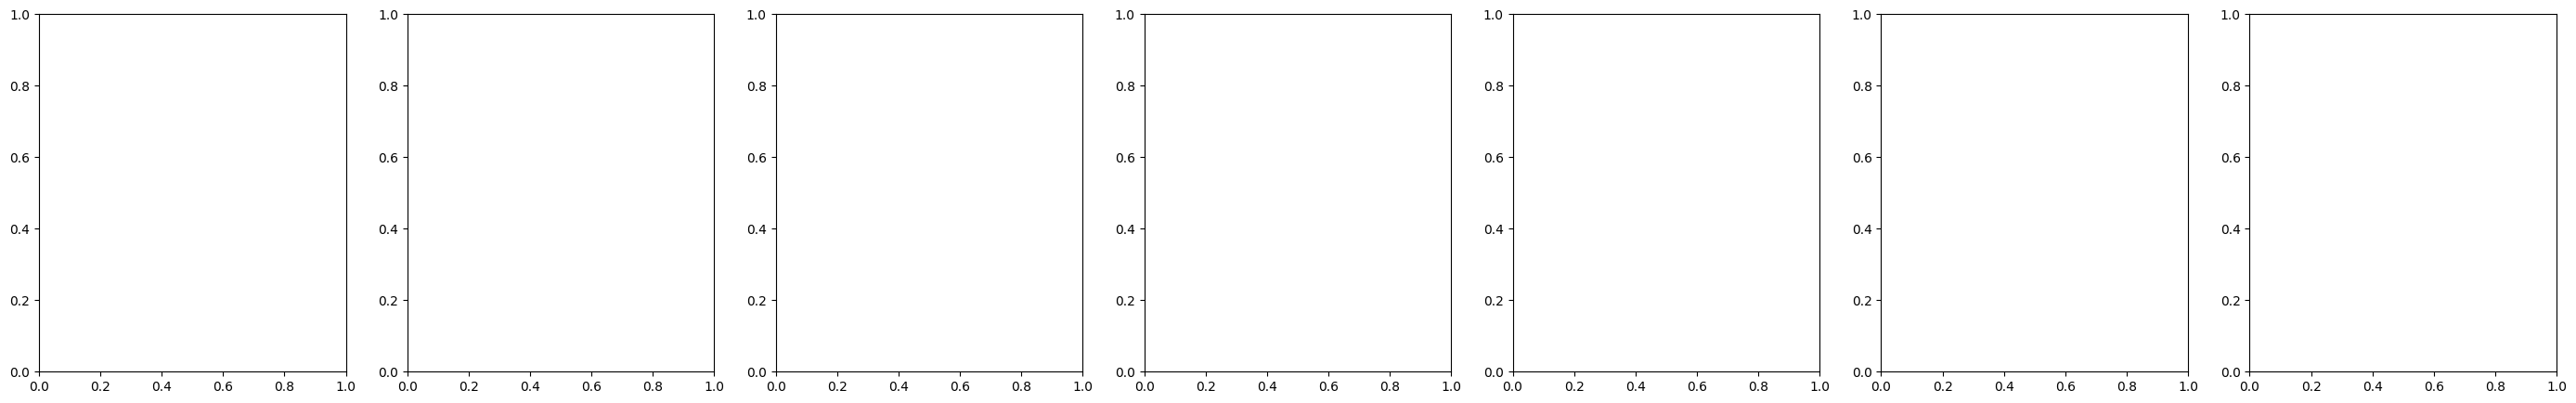

In [ ]:
# Setup subplots
fig, axes = plt.subplots(1, 7, figsize=(35, 5))
temperatures = [0.01, 1, 2, T_crit, 2.5, 3.5, 5] # Avoid T = 0
burns = np.linspace(0, 500, 21)
num_trials = 10

for i in range(len(temperatures)):
    print(f"Running T = {temperatures[i]:.3f}")
    # Initialize M to hold (trials, burn_steps)
    M = np.zeros((num_trials, len(burns)))

    for trial in range(num_trials):
        lattice = np.random.choice([-1, 1], size=(N, N))
        m_vals = np.zeros(len(burns))

        for a in range(len(burns)):
            # Perform sweeps between measurements
            for b in range(25):
                lattice = metropolis_sweep(lattice, temperatures[i], N)
            m_vals[a] = total_magnetization(lattice) / (N * N)

        M[trial] = m_vals

    # Average across the trials (axis 0)
    avg_M = np.mean(np.abs(M), axis=0) # Using abs because M can be +/-

    # Plotting
    axes[i].plot(burns, avg_M, label=f"T = {temperatures[i]:.2f}", color='red')
    axes[i].set_xlabel("Burn-in (Sweeps)")
    axes[i].set_ylabel("Avg Magnetization")
    axes[i].set_title(f"T = {temperatures[i]:.2f}")
    axes[i].grid(True, alpha=0.3)

NameError: name 'T_range' is not defined

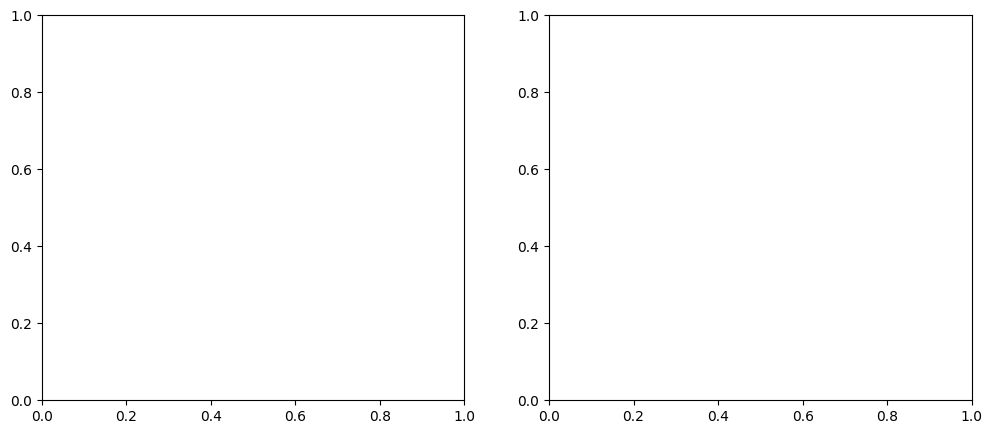

In [ ]:
# AI Generated
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Energy vs Temperature
ax1.plot(T_range, avg_E, "o-", color="#2c3e50", markersize=4) #plotting avg_E against T_range
ax1.axvline(x=2.269, color="gray", linestyle="--", alpha=0.7, label="$T_c$ (exact)")
ax1.set_xlabel("Temperature T")
ax1.set_ylabel("Energy per spin")
ax1.set_title("Energy vs Temperature")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Magnetization vs Temperature
ax2.plot(T_range, avg_M, "o-", color="#e74c3c", markersize=4)
ax2.axvline(x=2.269, color="gray", linestyle="--", alpha=0.7, label="$T_c$ (exact)")
ax2.set_xlabel("Temperature T")
ax2.set_ylabel("|Magnetization| per spin")
ax2.set_title("Magnetization vs Temperature")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("phase_transition.png", dpi=150)
plt.show()

In [ ]:
scalar_T_crit = 2 / np.log(1 + np.sqrt(2))
t_range = (T_range - scalar_T_crit) / scalar_T_crit
print(t_range)

NameError: name 'T_range' is not defined

In [ ]:
C = np.gradient(avg_E, t_range)

plt.figure(figsize=(8, 5))
plt.plot(t_range, C, "o-", color="#3498db", markersize=4)
plt.xlabel("t")
plt.ylabel("Heat Capacity C")
plt.title("Heat Capacity vs t")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("heat_capacity.png", dpi=150)
plt.show()

NameError: name 'avg_E' is not defined

In [33]:
data = np.load("ising_data-1.npz")
T_range = data["T_range"]
mean_M_arr = data["mean_M_arr"]
std_M_arr = data["std_M_arr"]

In [27]:
print(T_range)
print(mean_M_arr)
print(std_M_arr)

[0.5        0.65       0.8        0.95       1.1        1.25
 1.4        1.55       1.7        1.85       2.         2.025
 2.05       2.075      2.1        2.125      2.15       2.175
 2.2        2.225      2.25       2.275      2.3        2.325
 2.35       2.375      2.4        2.425      2.45       2.475
 2.5        2.66666667 2.83333333 3.         3.16666667 3.33333333
 3.5        3.66666667 3.83333333 4.        ]
[0.9999984  0.99998773 0.99991093 0.99952853 0.99844267 0.9960192
 0.99121333 0.98369547 0.9695216  0.949032   0.90317867 0.90395573
 0.8923232  0.8778688  0.872976   0.85671947 0.7666592  0.74541653
 0.76666773 0.73248213 0.49788533 0.28997493 0.27198293 0.20755307
 0.2274016  0.2282032  0.23167733 0.18048853 0.1302672  0.10232533
 0.128192   0.08390987 0.06137387 0.0597904  0.04599947 0.046352
 0.03990027 0.037952   0.03561813 0.03146293]
[2.26274170e-06 6.70389605e-06 1.38461387e-05 1.65419332e-05
 4.32164578e-05 6.22562447e-05 9.15439906e-05 8.32444326e-05
 5.07017422

<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1115/2033051166.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\ln|\\tau|$')
/tmp/ipykernel_1115/2033051166.py:47: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\ln(M)$')


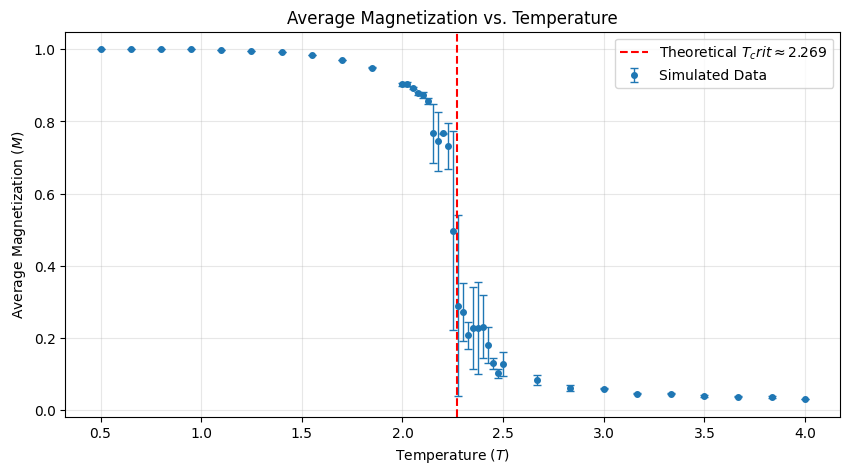

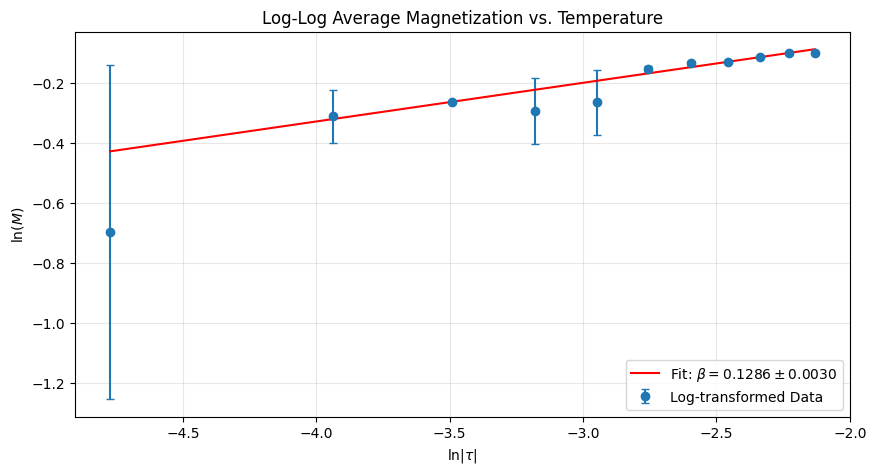

Calculated Beta: 0.1286 +/- 0.0030
Theoretical Beta: 0.125


In [30]:
plt.figure(figsize=(10, 5))
plt.errorbar(T_range, mean_M_arr, yerr=std_M_arr, fmt='o', markersize=4,
             capsize=3, elinewidth=1, label='Simulated Data')
plt.axvline(T_crit, color='red', linestyle='--', label=f'$T_c \\approx {T_c:.3f}$')
plt.xlabel('Temperature ($T$)')
plt.ylabel('Average Magnetization ($m$)')
plt.title('Average Magnetization vs. Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- PART 2: LOG-LOG PLOT & ERROR PROPAGATION ---
# Filter for T < Tc (the ordered phase), but not too low
mask = (T_range < T_crit) & (T_range > 1.96)
T_filt = T_range[mask]
M_filt = mean_M_arr[mask]
dM_filt = std_M_arr[mask]

# Calculate reduced temperature tau
tau = (T_crit - T_filt) / T_crit

# Transform to log-space
x_log = np.log(tau)
y_log = np.log(M_filt)

# Propagate errors: d(ln M) = dM / M
# This converts the absolute error in M to a relative error in log space
dy_log = dM_filt / M_filt

# --- PART 3: LINEAR FIT ---
# Define linear function: y = slope * x + intercept
def linear_model(x, beta, C):
    return beta * x + C

# Use weighted least squares (curve_fit with sigma) to account for error bars
popt, pcov = curve_fit(linear_model, x_log, y_log, sigma=dy_log, absolute_sigma=True)
beta_measured, intercept = popt
beta_error = np.sqrt(pcov[0, 0])

# --- PART 4: LOG-LOG PLOT ---
plt.figure(figsize=(10, 5))
plt.errorbar(x_log, y_log, yerr=dy_log, fmt='o', capsize=3, label='Log-transformed Data')
plt.plot(x_log, linear_model(x_log, *popt), color='red',
         label=f'Fit: $\\beta = {beta_measured:.4f} \\pm {beta_error:.4f}$')

plt.xlabel('$\ln|\\tau|$')
plt.ylabel('$\ln(M)$')
plt.title('Log-Log Average Magnetization vs. Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Calculated Beta: {beta_measured:.4f} +/- {beta_error:.4f}")
print(f"Theoretical Beta: 0.125")

In [28]:
B_range = np.linspace(-0.5, 0.5, 41)
print(B_range)

[-0.5   -0.475 -0.45  -0.425 -0.4   -0.375 -0.35  -0.325 -0.3   -0.275
 -0.25  -0.225 -0.2   -0.175 -0.15  -0.125 -0.1   -0.075 -0.05  -0.025
  0.     0.025  0.05   0.075  0.1    0.125  0.15   0.175  0.2    0.225
  0.25   0.275  0.3    0.325  0.35   0.375  0.4    0.425  0.45   0.475
  0.5  ]


In [32]:
B_range = np.linspace(-0.5, 0.5, 41)
n_trials = 3
burn_in = 250
measure_sweeps = 500

# Storage for results
mean_M_B = []
std_error_M_B = []

for B in B_range:
    print(f"Running B = {B:.2f}")
    B = B
    trial_means = []
    for trial in range(n_trials):
        # Randomly initialize lattice
        if B > 0:
          p_positive = 0.6
        if B < 0:
          p_positive = 0.4
        if B == 0:
          p_positive = 0.5
        lattice = initialize(N, p_positive)

        # Burn-in
        for _ in range(burn_in):
            metropolis_sweep(lattice, T_crit, N)

        # Measurement phase
        m_samples = []
        for _ in range(measure_sweeps):
            metropolis_sweep(lattice, T_crit, N)
            m_samples.append(np.mean(lattice))

        trial_means.append(np.mean(m_samples))

    # Calculate mean and standard error across trials
    mean_M_B.append(np.mean(trial_means))
    std_error_M_B.append(np.std(trial_means) / np.sqrt(n_trials))

# Convert to arrays
mean_M_B = np.array(mean_M_B)
std_error_M_B = np.array(std_error_M_B)

# Save the arrays
np.savez("ising_delta_data.npz",
         B_range=B_range,
         mean_M_B=mean_M_B,
         std_error_M_B=std_error_M_B)

# Download the data
files.download('ising_delta_data.npz')

Running B = -0.50
Running B = -0.47
Running B = -0.45
Running B = -0.42
Running B = -0.40
Running B = -0.38
Running B = -0.35
Running B = -0.32
Running B = -0.30
Running B = -0.28
Running B = -0.25
Running B = -0.22
Running B = -0.20
Running B = -0.17
Running B = -0.15
Running B = -0.12
Running B = -0.10
Running B = -0.07
Running B = -0.05
Running B = -0.02
Running B = 0.00
Running B = 0.03
Running B = 0.05
Running B = 0.08
Running B = 0.10
Running B = 0.12
Running B = 0.15
Running B = 0.18
Running B = 0.20
Running B = 0.23
Running B = 0.25
Running B = 0.28
Running B = 0.30
Running B = 0.33
Running B = 0.35
Running B = 0.38
Running B = 0.40
Running B = 0.43
Running B = 0.45
Running B = 0.48
Running B = 0.50


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# Save the arrays
np.savez("ising_delta_data.npz",
         B_range=B_range,
         mean_M_B=mean_M_B,
         std_error_M_B=std_error_M_B)

NameError: name 'B_range' is not defined

In [34]:
data = np.load("ising_delta_data (2).npz")
B_range = data["B_range"]
mean_M_B = data["mean_M_B"]
std_error_M_B = data["std_error_M_B"]
print(B_range)
print(mean_M_B)
print(std_error_M_B)

[-0.5   -0.475 -0.45  -0.425 -0.4   -0.375 -0.35  -0.325 -0.3   -0.275
 -0.25  -0.225 -0.2   -0.175 -0.15  -0.125 -0.1   -0.075 -0.05  -0.025
  0.     0.025  0.05   0.075  0.1    0.125  0.15   0.175  0.2    0.225
  0.25   0.275  0.3    0.325  0.35   0.375  0.4    0.425  0.45   0.475
  0.5  ]
[-0.93879947 -0.93710773 -0.93411467 -0.93055947 -0.92793653 -0.92428907
 -0.92118027 -0.9164848  -0.9148256  -0.9104224  -0.90375893 -0.8980336
 -0.89105227 -0.8853472  -0.87745493 -0.86887627 -0.8566304  -0.84390827
 -0.82405333 -0.78414987  0.2472896   0.7720656   0.8174144   0.84588533
  0.85711573  0.86674507  0.87566133  0.88341707  0.89177707  0.89873973
  0.90403307  0.90835733  0.91366507  0.91653227  0.92238347  0.92551947
  0.92837387  0.930512    0.93308     0.93652587  0.9384144 ]
[4.73586987e-04 7.12510312e-04 2.29685724e-04 4.59376402e-04
 3.58293900e-04 2.18986866e-04 5.74037810e-05 3.46335842e-04
 7.35966376e-04 4.01947968e-04 8.37825871e-04 1.21991673e-03
 1.32017687e-04 7.2601262

<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3606/2439869020.py:43: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(x_log, linear_fit(x_log, *popt), 'r-', label=f'Slope $1/\delta$ = {slope_k:.4f}')
/tmp/ipykernel_3606/2439869020.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\ln|B|$')
/tmp/ipykernel_3606/2439869020.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\ln|m|$')
/tmp/ipykernel_3606/2439869020.py:46: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Log-Log Plot for Critical Exponent $\delta$ (B < 0)')


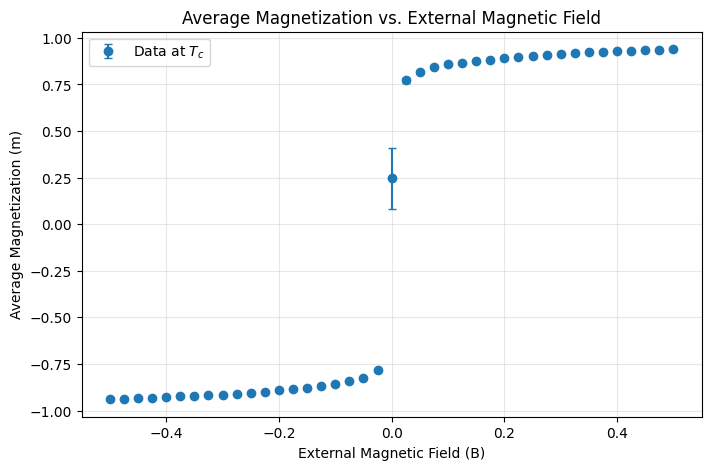

[-1.49165488 -1.60943791 -1.74296931 -1.89711998 -2.07944154 -2.30258509
 -2.59026717 -2.99573227 -3.68887945]
[-0.10754779 -0.11535219 -0.12177539 -0.13072968 -0.14055455 -0.15474873
 -0.16971148 -0.19352003 -0.24315512]
[0.00135843 0.00014816 0.00082003 0.00126565 0.0011326  0.00216691
 0.00188178 0.0033043  0.01165899]


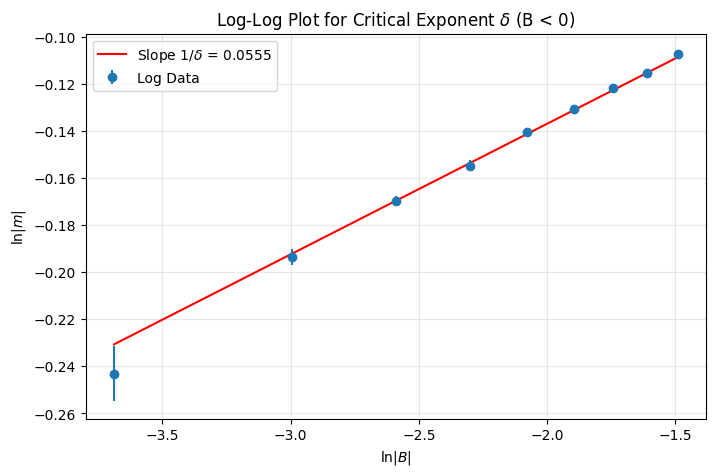

Calculated Delta: 18.0229 +/- 0.3613
Theoretical Delta: 15.0


In [41]:
#REGULAR PLOT
plt.figure(figsize=(8, 5))
plt.errorbar(B_range, mean_M_B, yerr=std_error_M_B, fmt='o', capsize=3, label='Data at $T_{c}$')
plt.xlabel('External Magnetic Field (B)')
plt.ylabel('Average Magnetization (m)')
plt.title('Average Magnetization vs. External Magnetic Field')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# LOG-LOG FIT
# Filter for positive B values to allow for log transformation
mask = (B_range < 0) & (B_range > -0.25)
B_filt = abs(B_range[mask])
M_filt = abs(mean_M_B[mask])
dM_filt = std_error_M_B[mask]

x_log = np.log(B_filt)
y_log = np.log(M_filt)

# Propagate error for log(M): d(log M) = dM / M
dy_log = dM_filt / M_filt

# Linear fit: y = kx + c
def linear_fit(x, k, c):
    return k * x + c

print(x_log)
print(y_log)
print(dy_log)
# Use curve_fit with weightings
popt, pcov = curve_fit(linear_fit, x_log, y_log, sigma=dy_log, absolute_sigma=True)
slope_k, intercept = popt
slope_err = np.sqrt(pcov[0, 0])

# Calculate delta and propagate error back: delta = 1/k
delta_val = 1 / slope_k
delta_err = (slope_err / (slope_k**2))

# --- PART C: LOG-LOG PLOT ---
plt.figure(figsize=(8, 5))
plt.errorbar(x_log, y_log, yerr=dy_log, fmt='o', label='Log Data')
plt.plot(x_log, linear_fit(x_log, *popt), 'r-', label=f'Slope $1/\delta$ = {slope_k:.4f}')
plt.xlabel('$\ln|B|$')
plt.ylabel('$\ln|m|$')
plt.title('Log-Log Plot for Critical Exponent $\delta$ (B < 0)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Calculated Delta: {delta_val:.4f} +/- {delta_err:.4f}")
print(f"Theoretical Delta: 15.0")

<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3606/2697750754.py:43: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(x_log, linear_fit(x_log, *popt), 'r-', label=f'Slope $1/\delta$ = {slope_k:.4f}')
/tmp/ipykernel_3606/2697750754.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\ln|B|$')
/tmp/ipykernel_3606/2697750754.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\ln|m|$')
/tmp/ipykernel_3606/2697750754.py:46: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Log-Log Plot for Critical Exponent $\delta$ (B > 0)')


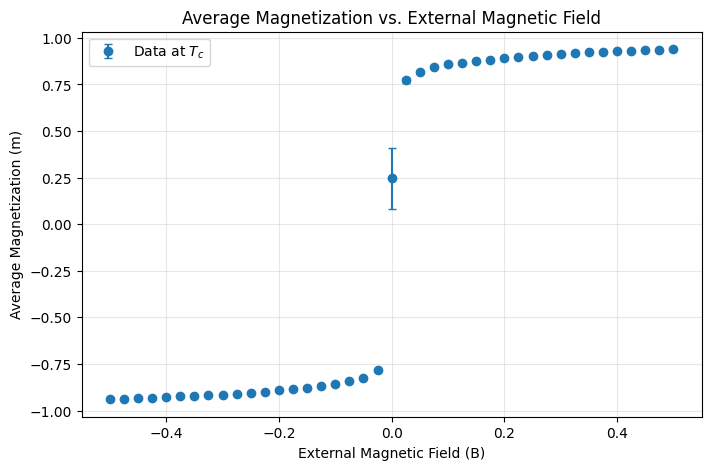

[-3.68887945 -2.99573227 -2.59026717 -2.30258509 -2.07944154 -1.89711998
 -1.74296931 -1.60943791 -1.49165488]
[-0.25868576 -0.20160909 -0.16737147 -0.15418232 -0.14301039 -0.13277587
 -0.12395786 -0.1145391  -0.10676179]
[0.01613766 0.00610076 0.00188928 0.001965   0.00046883 0.00245703
 0.00065155 0.00126813 0.00011896]


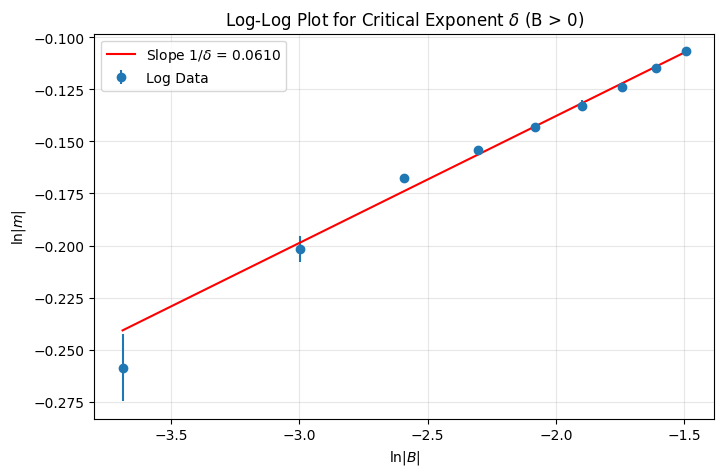

Calculated Delta: 16.4022 +/- 0.1837
Theoretical Delta: 15.0


In [42]:
#REGULAR PLOT
plt.figure(figsize=(8, 5))
plt.errorbar(B_range, mean_M_B, yerr=std_error_M_B, fmt='o', capsize=3, label='Data at $T_{c}$')
plt.xlabel('External Magnetic Field (B)')
plt.ylabel('Average Magnetization (m)')
plt.title('Average Magnetization vs. External Magnetic Field')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# LOG-LOG FIT
# Filter for positive B values to allow for log transformation
mask = (B_range > 0) & (B_range < 0.25)
B_filt = abs(B_range[mask])
M_filt = abs(mean_M_B[mask])
dM_filt = std_error_M_B[mask]

x_log = np.log(B_filt)
y_log = np.log(M_filt)

# Propagate error for log(M): d(log M) = dM / M
dy_log = dM_filt / M_filt

# Linear fit: y = kx + c
def linear_fit(x, k, c):
    return k * x + c

print(x_log)
print(y_log)
print(dy_log)
# Use curve_fit with weightings
popt, pcov = curve_fit(linear_fit, x_log, y_log, sigma=dy_log, absolute_sigma=True)
slope_k, intercept = popt
slope_err = np.sqrt(pcov[0, 0])

# Calculate delta and propagate error back: delta = 1/k
delta_val = 1 / slope_k
delta_err = (slope_err / (slope_k**2))

# --- PART C: LOG-LOG PLOT ---
plt.figure(figsize=(8, 5))
plt.errorbar(x_log, y_log, yerr=dy_log, fmt='o', label='Log Data')
plt.plot(x_log, linear_fit(x_log, *popt), 'r-', label=f'Slope $1/\delta$ = {slope_k:.4f}')
plt.xlabel('$\ln|B|$')
plt.ylabel('$\ln|m|$')
plt.title('Log-Log Plot for Critical Exponent $\delta$ (B > 0)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Calculated Delta: {delta_val:.4f} +/- {delta_err:.4f}")
print(f"Theoretical Delta: 15.0")